### 1) import et chargement

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [4]:
rfm = pd.read_csv('../data/rfm_scores.csv')
rfm

,Customer ID,Recency,Frequency,Monetary,R,F,M,RFM_Score,Segment
0,12346,165,11,372.86,2,5,2,9,Clients Moyens
1,12347,3,2,1323.32,5,2,4,11,Nouveaux Clients
2,12348,74,1,222.16,2,1,1,4,Clients Endormis
3,12349,43,3,2671.14,3,3,5,11,Clients Fidèles
4,12351,11,1,300.93,5,1,2,8,Nouveaux Clients
...,...,...,...,...,...,...,...,...,...
4307,18283,18,6,641.77,4,5,3,12,Clients Fidèles
4308,18284,67,1,461.68,3,2,2,7,Clients Moyens
4309,18285,296,1,427.00,1,2,2,5,Clients Endormis
4310,18286,112,2,1296.43,2,3,4,9,Clients Perdus


### 2) Visualisation

In [5]:
os.makedirs('figures', exist_ok=True)
sns.set_theme(style="whitegrid")

#### 1) Histogrammes R, F , M

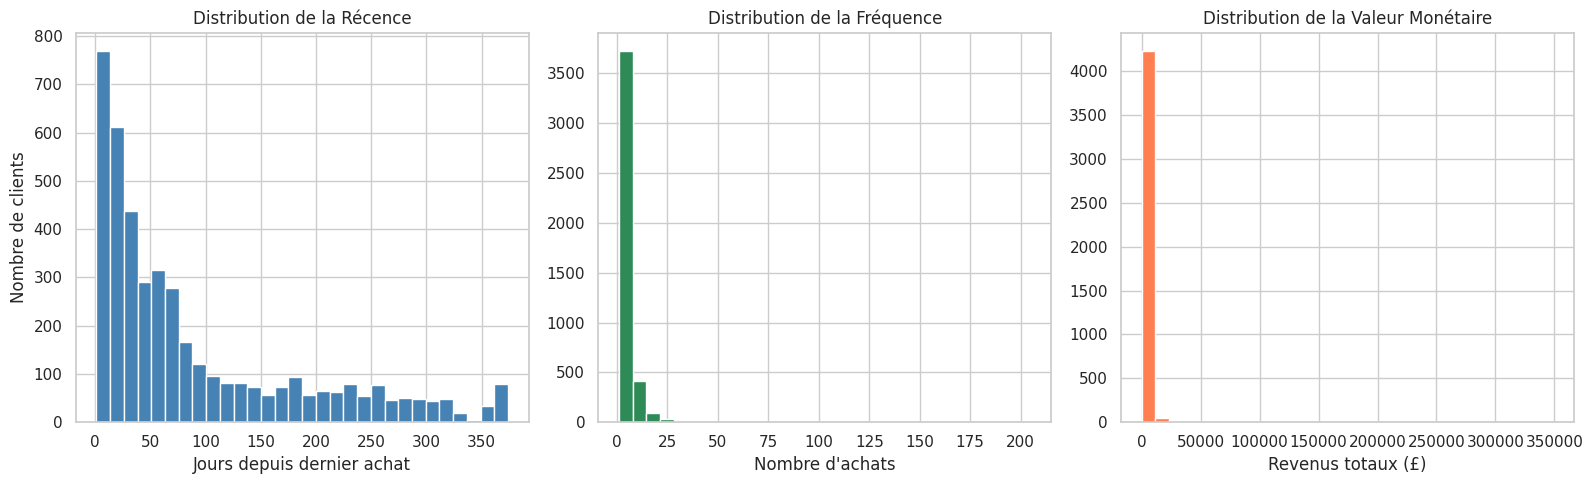

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(rfm['Recency'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution de la Récence')
axes[0].set_xlabel('Jours depuis dernier achat')
axes[0].set_ylabel('Nombre de clients')

axes[1].hist(rfm['Frequency'], bins=30, color='seagreen', edgecolor='white')
axes[1].set_title('Distribution de la Fréquence')
axes[1].set_xlabel("Nombre d'achats")

axes[2].hist(rfm['Monetary'], bins=30, color='coral', edgecolor='white')
axes[2].set_title('Distribution de la Valeur Monétaire')
axes[2].set_xlabel('Revenus totaux (£)')

plt.tight_layout()
plt.savefig('figures/histogrammes_rfm.png', dpi=150)
plt.show()

#### 2) Heatmap dépense moyenne selon R et F 

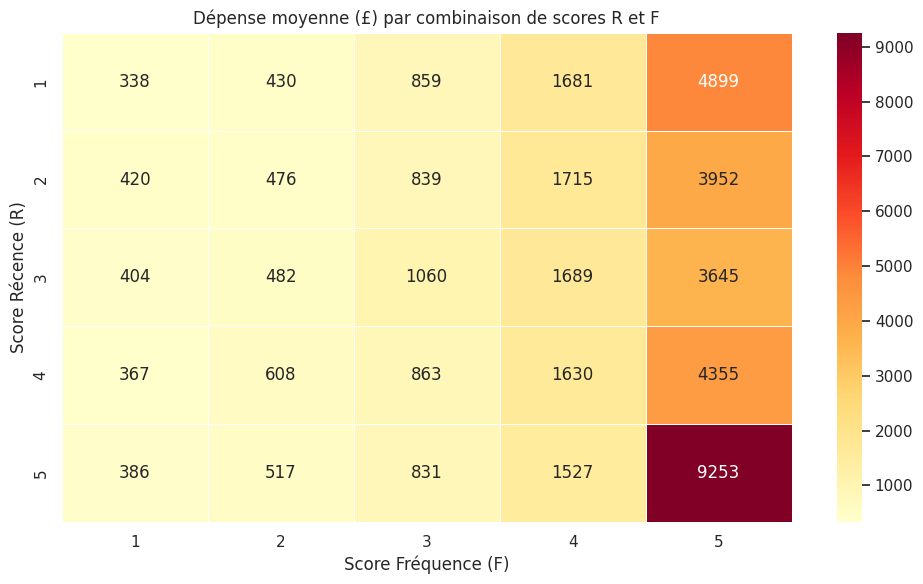

In [7]:
heatmap_data = rfm.groupby(['R', 'F'])['Monetary'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Dépense moyenne (£) par combinaison de scores R et F')
plt.xlabel('Score Fréquence (F)')
plt.ylabel('Score Récence (R)')
plt.tight_layout()
plt.savefig('figures/heatmap_R_F.png', dpi=150)
plt.show()

#### 3) Diagrammes en barres des segments

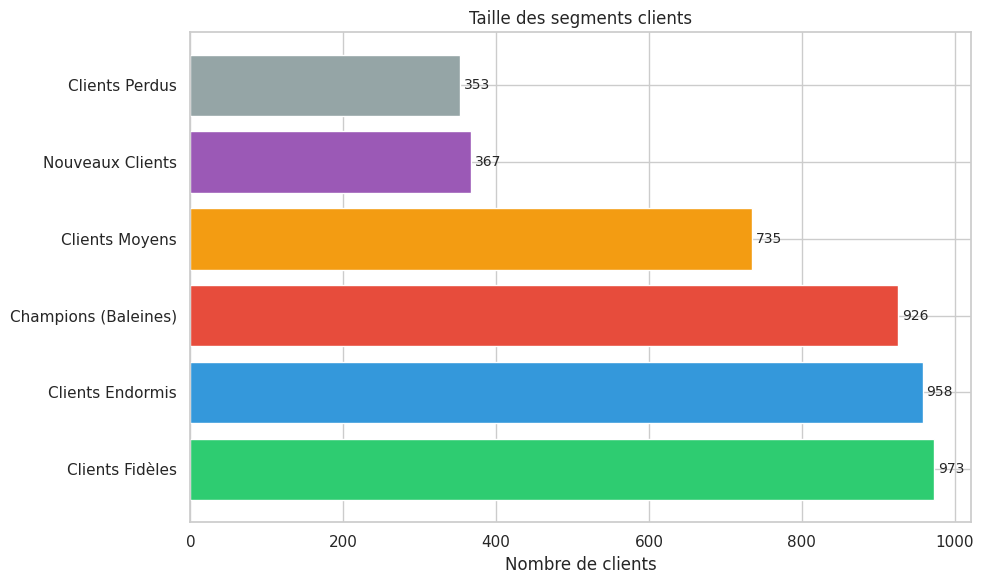

In [8]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Nombre de clients']

plt.figure(figsize=(10, 6))
colors = ['#2ecc71','#3498db','#e74c3c','#f39c12','#9b59b6','#95a5a6']
bars = plt.barh(
    segment_counts['Segment'],
    segment_counts['Nombre de clients'],
    color=colors
)
plt.title('Taille des segments clients')
plt.xlabel('Nombre de clients')
for bar, val in zip(bars, segment_counts['Nombre de clients']):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
plt.tight_layout()
plt.savefig('figures/segments_barres.png', dpi=150)
plt.show()

#### 4) Nuage de point F Vs M coloré en R

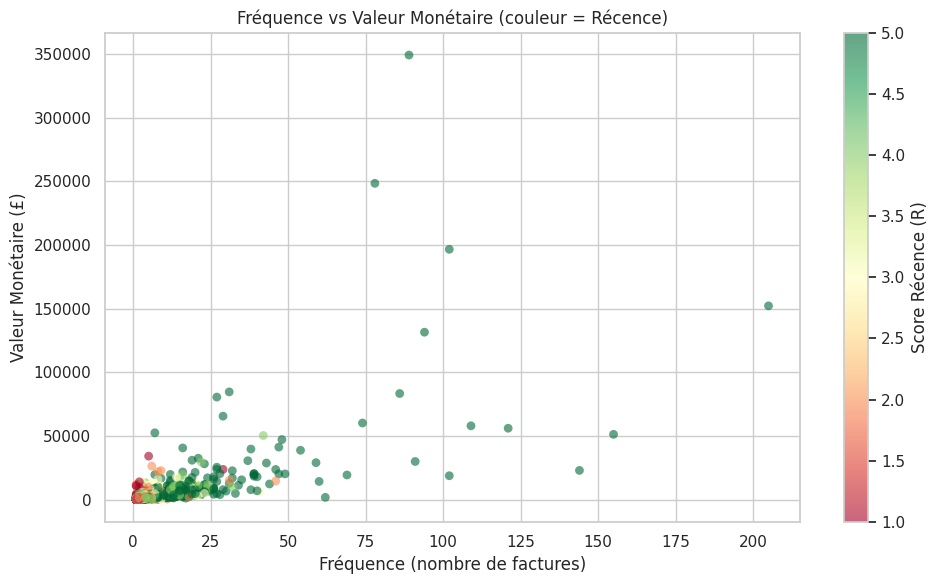

In [9]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['R'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='none',
    s=40
)
plt.colorbar(scatter, label='Score Récence (R)')
plt.title('Fréquence vs Valeur Monétaire (couleur = Récence)')
plt.xlabel('Fréquence (nombre de factures)')
plt.ylabel('Valeur Monétaire (£)')
plt.tight_layout()
plt.savefig('figures/scatter_F_M_R.png', dpi=150)
plt.show()

#### 5) Résumé des segments

In [12]:
summary = rfm.groupby('Segment').agg(
    Nb_clients=('Customer ID', 'count'),
    Recence_moy=('Recency', 'mean'),
    Frequence_moy=('Frequency', 'mean'),
    Monetaire_moy=('Monetary', 'mean')
).round(1).sort_values('Nb_clients', ascending=False)
summary

,Nb_clients,Recence_moy,Frequence_moy,Monetaire_moy
Segment,,,,
Clients Fidèles,973,36.1,3.9,1350.6
Clients Endormis,958,214.9,1.1,287.5
Champions (Baleines),926,13.7,11.7,6187.6
Clients Moyens,735,111.1,2.0,492.4
Nouveaux Clients,367,19.8,1.3,503.2
Clients Perdus,353,143.3,4.4,2736.9
